# Rdkit, the molecular playground

As chemists, you probably would like to be able to manipulate molecular data in your future programs! You have already started to do that by creating your own `Molecule` class in this lecture, but as you have seen working with molecules is actually rather complicated... Fortunately there is a library for that! 😃

The library is called `rdkit`. This is a third-party library, meaning that you need to install it before using it. To do so, open your Windows terminal, activate your python environment and install the library with `pip install rdkit`. Note that usually we use `conda install`, but in that case the conda repository gives an rdkit version that has some bugs.

There are so many possibilities offered by rdkit that we could do an entire lecture on this library. Here, we will just see how to perform the tasks we have implemented with our home-made `Molecule` class in just a couple of lines. To see examples of other advanced functionnalities of the `rdkit` library, you can have a look at this nice [rdkit tutorial webpage](https://www.rdkit.org/docs/Cookbook.html).

But for now, let us try to analyze a few molecules as we have done before, looking at their chemical formula, molar mass, and if they are alcohol or not. Let's first define an ethanol molecule by a tuple containing the molecule name and the molecule SMILES:

In [13]:
# Define the molecule by its name and SMILES code
molecule = ("ethanol", "CCO")

The most basic, but also probably the most interesting capability of rdkit, is to draw the molecular structure, just from the SMILES code. To do so, let's first create a `Mol` object, that is a class representing a molecule defined in `rdkit`: 

In [14]:
# The module required to create Mol object
from rdkit import Chem

# Mol created from the SMILES code
mol = Chem.MolFromSmiles(molecule[1])

Now here is the cool thing, just by runnning a noteook cell with the name of the `Mol` object, you will be able to visualize the molecular structure:

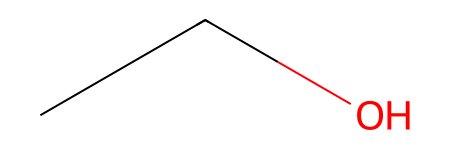

In [15]:
mol

The chemical formula and molar mass are so-called molecular descriptors in `rdkit`, they can be easily calculated by using dedicated modules of the library, that defined functions acting on the `Mol` object (they are not methods but functions!): 

In [16]:
# Required modules to calculate molecular descriptors
from rdkit.Chem import Descriptors, rdMolDescriptors

# Get and print the molecule raw formula
formula = rdMolDescriptors.CalcMolFormula(mol)
print(f"{molecule[0]} formula is {formula}")

# Get and print the molar mass
mass = Descriptors.ExactMolWt(mol)
print(f"{molecule[0]} molar mass is {mass} g/mol")

ethanol formula is C2H6O
ethanol molar mass is 46.041864812 g/mol


Now to determine if the molecule is an alcohol or not, we will use a very powerful feature of `rdkit`, the substructure search: this is a way to check if the molecule contains a particular group in it's molecular structure. To do so, we first need to define which group we are looking at. The group is defined with a **SMARTS code**, which is rather similar to SMILES but which allows for more precise definition of the structure. You can learn more about SMARTS code on this [SMARTS tutorial webpage](https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html). The SMARTS code corresponding to an alcohol group is defined as followed:

In [17]:
alcohol_smarts = Chem.MolFromSmarts("[CX4][OX2H]")

This SMARTS code means "an aliphatic carbon" ([CX4]) bounds to "an OH group" ([OX2H]). Now, to check if the molecule contains this group, we will use the `GetSubstructMatches` method of the `Mol` object:

In [18]:
# Return all occurence of the subgroup in the molecule
alcohol_match = mol.GetSubstructMatches(alcohol_smarts)

# Check if the molecule is an alcohol, i.e. if it contains at least one alcohol group
is_alcohol = len(alcohol_match) > 0
print(f"Is {molecule[0]} an alcohol: {is_alcohol}")

Is ethanol an alcohol: True


````{admonition} Exercice
:class: tip
:label: exo_rdkit

Visualize the molecular structure and calculate the formula, molar mass, and determine if the following molecules are alcohol:

water -> O <br>
ethanol -> CCO <br>
urea -> C(=O)(N)N <br>
pentane -> CCCCC <br>
acetic acid -> CC(=O)O <br>
propanol -> CCCO <br>
formaldehyde -> C=O <br>

````

````{dropdown} Solution
```{code-cell}

# Required modules for Mol creation and descriptor calculations
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# Required module to explicitely show the molecular structures (when several need to be displayed)
from rdkit.Chem import Draw

def analyze_molecule(molecule):

    print(10*"=")

    # Mol created from the SMILES code
    mol = Chem.MolFromSmiles(molecule[1])

    # Draw the molecular structure (here we need to explicitely call dispaly(img) as we have several molecules to display)
    img = Draw.MolToImage(mol)
    display(img)
        
    # Get and print the molecule raw formula
    formula = rdMolDescriptors.CalcMolFormula(mol)
    print(f"{molecule[0]} formula is {formula}")
    
    # Get and print the molar mass
    mass = Descriptors.ExactMolWt(mol)
    print(f"{molecule[0]} molar mass is {mass} g/mol")
    
    # Return all occurence of the subgroup in the molecule
    alcohol_smarts = Chem.MolFromSmarts("[CX4][OX2H]")
    alcohol_match = mol.GetSubstructMatches(alcohol_smarts)
    
    # Check if the molecule is an alcohol, i.e. if it contains at least one alcohol group
    is_alcohol = len(alcohol_match) > 0
    print(f"Is {molecule[0]} an alcohol: {is_alcohol}")

    print(10*"=")
    print("\n")


molecule_list = [ ("water", "O"), ("ethanol", "CCO"), ("urea", "C(=O)(N)N"), ("pentane", "CCCCC"), ("acetic acid", "CC(=O)O"), ("propanol", "CCCO"), ("formaldehyde", "C=O") ]

for mol in molecule_list:
    analyze_molecule(mol)
    

```
````